In [1]:
%pip install pandas numpy matplotlib seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import sklearn as sl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

### Varibles del dataset 

age. Edad del beneficiario principal (numérico)

sex. Género del beneficiario principal (categórico)

bmi. índice de masa corporal (numérico)

children. Número de niños/dependientes cubiertos por un seguro médico (numérico)

smoker. ¿Es fumador? (categórico)

region. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)

charges. Prima del seguro médico (numérico)

In [ ]:
df_ini = pd.read_csv('data/raw/medical_insurance_cost.csv')
df_ini.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### I.- Revisión inicial del dataset

In [4]:
df_ini.shape

(1338, 7)

In [5]:
df_ini.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


El dataset tiene 1338 registros y siete columnas, no tiene valores nulos, tiene dos variables tipo "float" tres variables tipo "str" y dos variables (int)

### II.- Análisis Expliratorio de Datos 

Revisión y tratamiento de las posibles variables categóricas 

In [6]:
# Revisión de loas variables de texto 
var_texto = df_ini.select_dtypes(include=['str', 'object']).columns.tolist()
print("Posibles variables categoricas:")
print(var_texto)

Posibles variables categoricas:
['sex', 'smoker', 'region']


In [7]:
# Extraer los valores únicos
valores_unicos = df_ini['region'].unique()
print(f"Valores únicos para la variable '{'region'}':\n")
print(valores_unicos)

Valores únicos para la variable 'region':

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


Revisión de datos numéricos 

In [8]:
df_ini.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


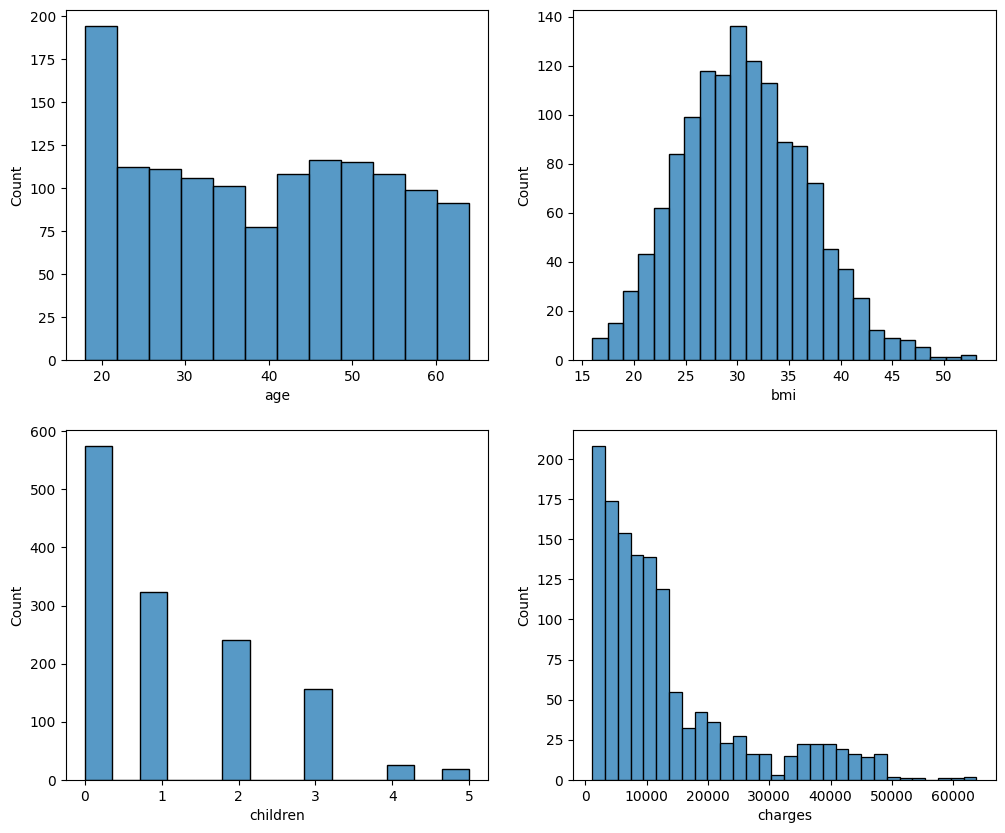

In [9]:
fig, axs = plt.subplots(2,2, figsize=(12,10))
sns.histplot(df_ini['age'],ax=axs [0,0])
sns.histplot(df_ini['bmi'],ax=axs [0,1])
sns.histplot(df_ini['children'],ax=axs [1,0])
sns.histplot(df_ini['charges'],ax=axs [1,1]);

Diagrama de correlaciones 

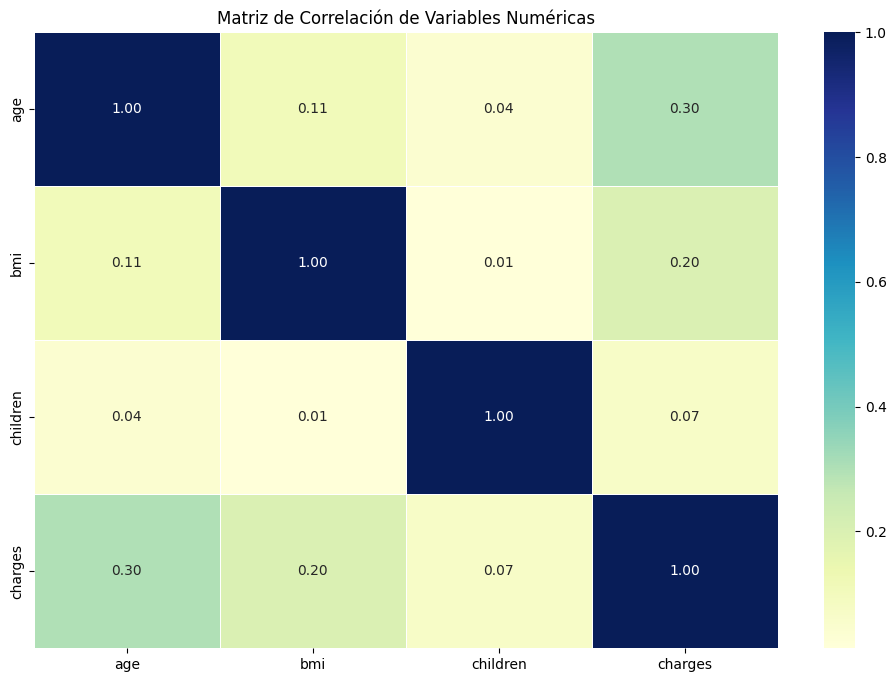

In [10]:
# Matriz de Correlación del nuevo Dataset_ =  
numerics = df_ini.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerics.corr()

_ = plt.figure(figsize=(12, 8))
_ = sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
_ = plt.title('Matriz de Correlación de Variables Numéricas')
_ = plt.show();

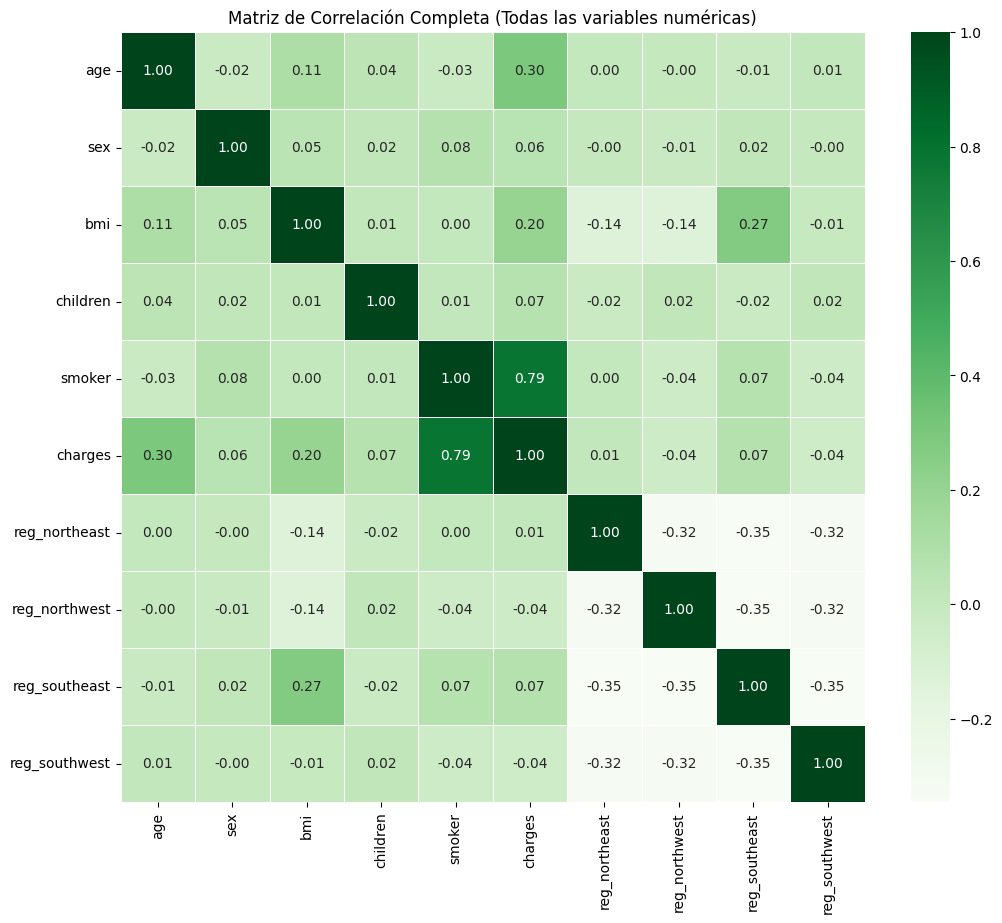

Correlación de todas las variables con 'charges':
charges          1.000000
smoker           0.787251
age              0.299008
bmi              0.198341
reg_southeast    0.073982
children         0.067998
sex              0.057292
reg_northeast    0.006349
reg_northwest   -0.039905
reg_southwest   -0.043210
Name: charges, dtype: float64


In [11]:

# 2. Transformación de variables categóricas
df_numeric = df_ini.copy()

# Variables binarias categoricas
df_numeric['sex'] = df_numeric['sex'].map({'female': 0, 'male': 1})
df_numeric['smoker'] = df_numeric['smoker'].map({'no': 0, 'yes': 1})

# Variable con múltiples categorías (Region) usando One-Hot Encoding
# Esto crea una columna por cada región 
df_numeric = pd.get_dummies(df_numeric, columns=['region'], prefix='reg')

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Visualización
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación Completa (Todas las variables numéricas)')
plt.show()

# 5. Ver específicamente la correlación con los cargos (ordenada)
print("Correlación de todas las variables con 'charges':")
print(correlation_matrix['charges'].sort_values(ascending=False));

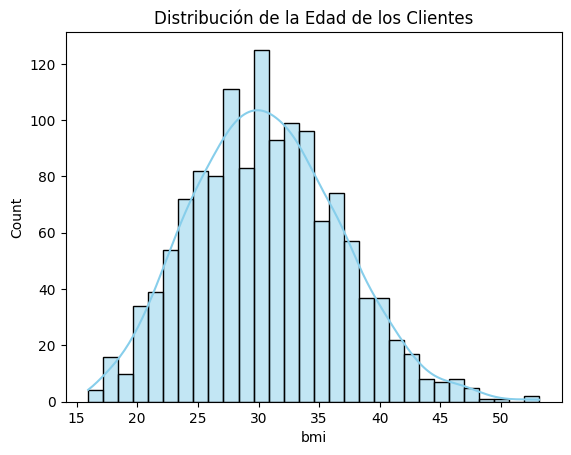

In [12]:
# Distribución de la Edad (Numérica)
_ = plt.figure()
_ = sns.histplot(data=df_ini, x='bmi', bins=30, kde=True, color='skyblue')
_ = plt.title('Distribución de la Edad de los Clientes')
_ = plt.show()

La variable que veo con menos informacion relevante es la region  

Diferencia por ser fumador: 23615.96 USD
Diferencia máxima entre regiones: 2388.47 USD


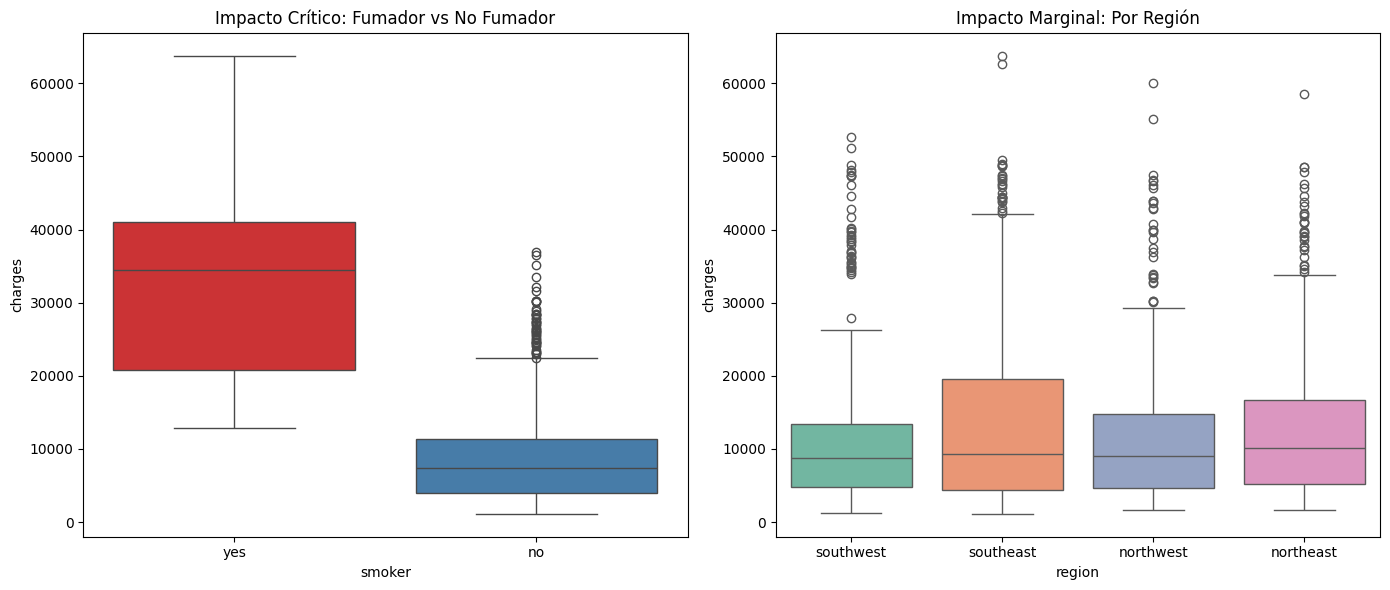

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset
df_ini = pd.read_csv('data/raw/medical_insurance_cost.csv')

# 1. Análisis Numérico
smoker_impact = df_ini.groupby('smoker')['charges'].mean()
region_impact = df_ini.groupby('region')['charges'].mean()

print(f"Diferencia por ser fumador: {smoker_impact['yes'] - smoker_impact['no']:.2f} USD")
print(f"Diferencia máxima entre regiones: {region_impact.max() - region_impact.min():.2f} USD")

# 2. Visualización corregida para evitar FutureWarning
plt.figure(figsize=(14, 6))

# Gráfico para Fumadores: se añade hue='smoker' y legend=False
plt.subplot(1, 2, 1)
sns.boxplot(x='smoker', y='charges', data=df_ini, hue='smoker', palette='Set1', legend=False)
plt.title('Impacto Crítico: Fumador vs No Fumador')

# Gráfico para Región: se añade hue='region' y legend=False
plt.subplot(1, 2, 2)
sns.boxplot(x='region', y='charges', data=df_ini, hue='region', palette='Set2', legend=False)
plt.title('Impacto Marginal: Por Región')



plt.tight_layout()
plt.show();

Como era de esperarse, el ser fumador aumenta el riesgo para la compañía de seguros; en consecuencia, la póliza tiende a aumentar de costo.

Tratamiento de la variable región 

In [14]:
df_ini['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

En la variable región también hay una tendencia; es decir, cuando la región está al sureste, la prima tiende a aumentar, al igual que al noreste, y en el noroeste es mayor que en el suroeste. He descartado que sea una estrategia de aseguramiento colectivo en la que, mientras más personas de una región se aseguran, el precio disminuye, porque la cantidad de registros es similar; lo que me lleva a concluir que posiblemente se trate de una situación de riesgo por ubicación

In [15]:
# Agrupamos por región y calculamos max y min de los cargos
analisis_region = df_ini.groupby('region')['charges'].agg(['max', 'min']).reset_index()

# Calculamos la diferencia (rango)
analisis_region['diferencia'] = analisis_region['max'] - analisis_region['min']

# Ordenamos de mayor a menor diferencia
analisis_region = analisis_region.sort_values(by='diferencia', ascending=False)

print(analisis_region)

      region          max        min   diferencia
2  southeast  63770.42801  1121.8739  62648.55411
1  northwest  60021.39897  1621.3402  58400.05877
0  northeast  58571.07448  1694.7964  56876.27808
3  southwest  52590.82939  1241.5650  51349.26439


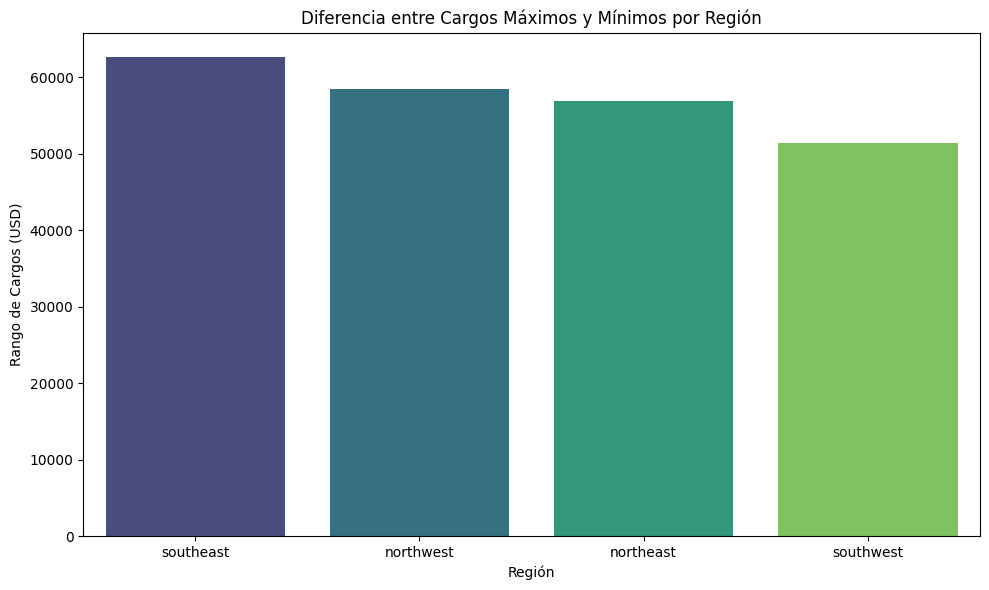

In [16]:
import warnings
warnings.filterwarnings('ignore')

# Calcular Max, Min y Rango por cada región
region_analysis = df_ini.groupby('region')['charges'].agg(['max', 'min']).reset_index()
region_analysis['difference_range'] = region_analysis['max'] - region_analysis['min']
region_analysis = region_analysis.sort_values(by='difference_range', ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
g = sns.barplot(x='region', y='difference_range', data=region_analysis, palette='viridis', hue='region', dodge=False)
plt.title('Diferencia entre Cargos Máximos y Mínimos por Región')
plt.ylabel('Rango de Cargos (USD)')
plt.xlabel('Región')
g.legend().remove()
plt.tight_layout()
plt.show();

Entendiendo que esta variable es estática —es decir, solo influye como un multiplicador fuera del perfil personal—, la voy a tratar como un coeficiente de ajuste por región.

In [17]:
import warnings

# SINTAXIS PARA ELIMINAR WARNINGS
warnings.filterwarnings('ignore') 

# Calcular la referencia nacional (Media Global)
media_nacional = df_ini['charges'].mean()

# Calcular el Coeficiente de Ajuste Geográfico (GAC)
# Este coeficiente indica cuánto se desvía cada región del promedio nacional
resumen_regional = df_ini.groupby('region')['charges'].mean().reset_index()
resumen_regional.columns = ['Región', 'Cargo Promedio']
resumen_regional['Coeficiente'] = resumen_regional['Cargo Promedio'] / media_nacional

# 4. Calcular el impacto porcentual directo
resumen_regional['Impacto %'] = (resumen_regional['Coeficiente'] - 1) * 100

# Ordenamos por el coeficiente más alto (las regiones más caras primero)
resumen_regional = resumen_regional.sort_values(by='Coeficiente', ascending=False)

print(f"VALOR DE REFERENCIA (Media Nacional): ${media_nacional:,.2f}\n")
print(resumen_regional[['Región', 'Coeficiente', 'Impacto %']].to_string(index=False))

VALOR DE REFERENCIA (Media Nacional): $13,270.42

   Región  Coeficiente  Impacto %
southeast     1.110395  11.039507
northeast     1.010246   1.024551
northwest     0.935733  -6.426675
southwest     0.930410  -6.958971


Estos valores los utilizaré para penalizar el costo al final de cada predicción. 

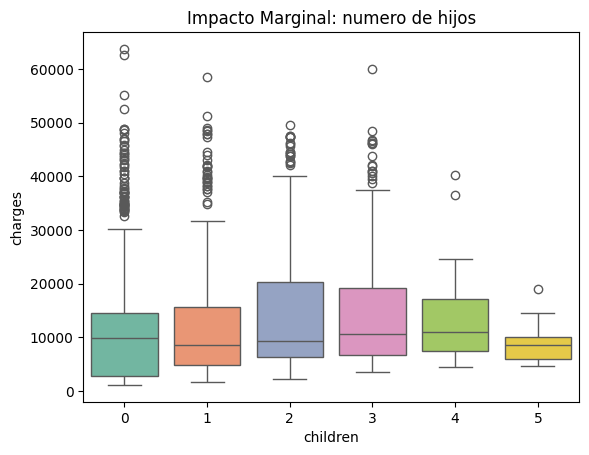

In [18]:
# Gráfico para Región: se añade hue='region' y legend=False

sns.boxplot(x='children', y='charges', data=df_ini, hue='children', palette='Set2', legend=False)
plt.title('Impacto Marginal: numero de hijos');

Los outliers de estos gráficos no representan dispersiones ni desviaciones; representan costos incrementales por otros criterios en individuos que pertenecen a alguna característica. Por lo tanto, no voy a tratar los outliers.

Además, se observa un patrón en el que el costo de la prima aumenta por los tres primeros hijos; luego, tiende a bajar.

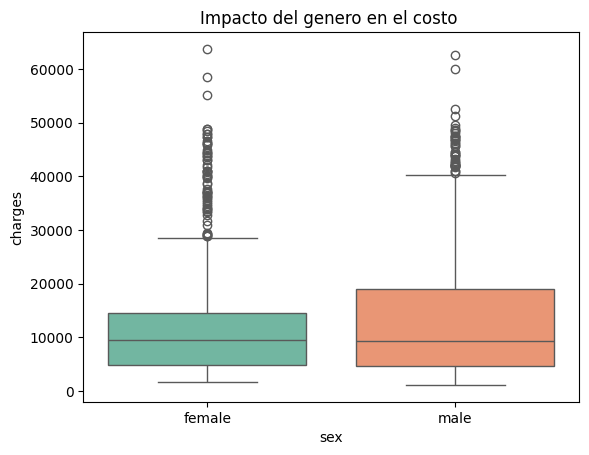

In [19]:
# Gráfico para Sex: se añade hue='sex' y 

sns.boxplot(x='sex', y='charges', data=df_ini, hue='sex', palette='Set2', legend=False)
plt.title('Impacto del genero en el costo ');

El género también representa un diferenciador en el costo de la prima y, una vez más, los outliers representan un aumento de la prima por condiciones adicionales al perfil.

### Estudio Multivariable 

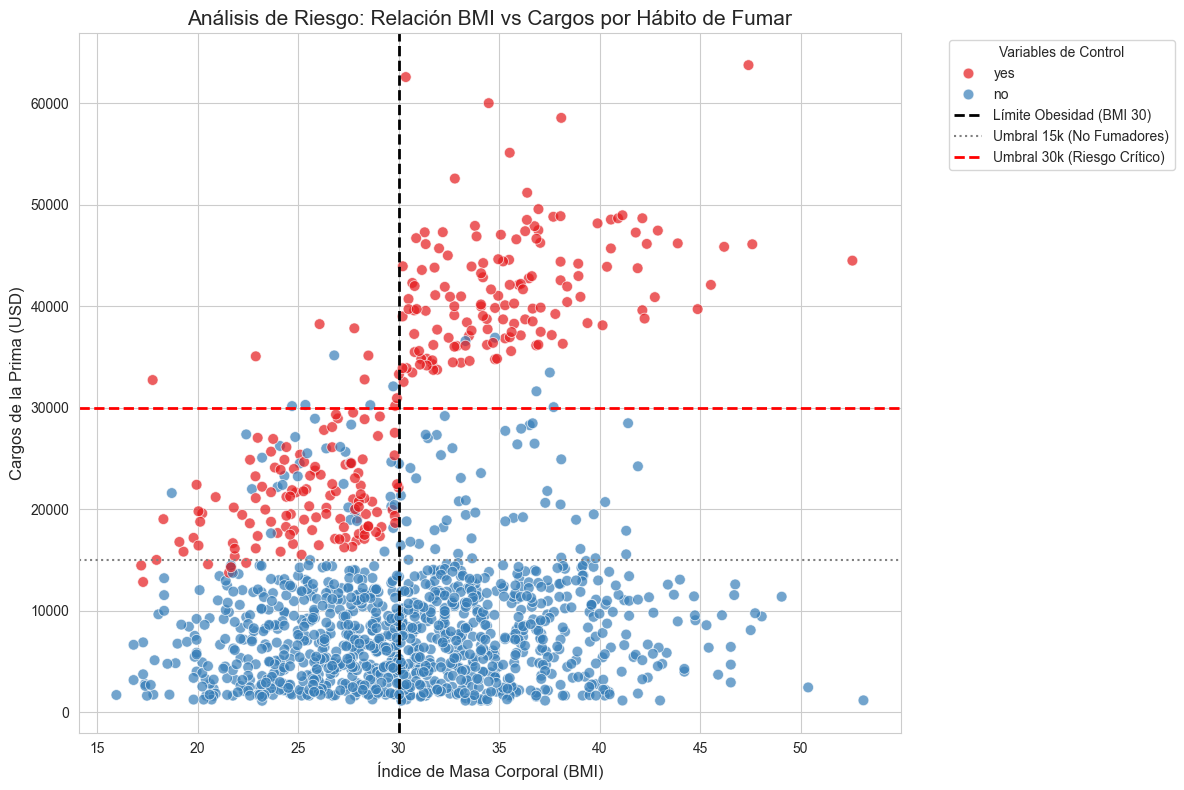

In [20]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))


# x: BMI, y: Charges
sns.scatterplot(data=df_ini, x='bmi', y='charges', hue='smoker', 
                palette='Set1', alpha=0.7, s=60)

# Línea vertical para el límite de obesidad
plt.axvline(x=30, color='black', linestyle='--', linewidth=2, label='Límite Obesidad (BMI 30)')

# Líneas horizontales para los niveles de costo
plt.axhline(y=15000, color='gray', linestyle=':', linewidth=1.5, label='Umbral 15k (No Fumadores)')
plt.axhline(y=30000, color='red', linestyle='--', linewidth=2, label='Umbral 30k (Riesgo Crítico)')
plt.title('Análisis de Riesgo: Relación BMI vs Cargos por Hábito de Fumar', fontsize=15)
plt.xlabel('Índice de Masa Corporal (BMI)', fontsize=12)
plt.ylabel('Cargos de la Prima (USD)', fontsize=12)
plt.legend(title='Variables de Control', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show();


En este gráfico se muestra cómo los perfiles de alto riesgo, como personas fumadoras y con un índice de masa corporal alto, representan un riesgo mayor; por lo tanto, el costo de la póliza es mayor. Además, la escala de costo muestra un patrón bien definido en los seis perfiles de cliente que se muestran en este gráfico.

### Creacion de perfiles de riesgo

Como estrategia he decidido crear perfiles de riesgo basados en edad, indice de masa corporal, sexo y si fuma o no usando K-means 

Esta primera parte de la segmentacin utilízo un escalador para que la variables tengan el mismo peso 

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df_limpio = df_numeric.copy()

# Seleccionamos las variables para el modelo (sin 'charges' para segmentar por perfil de salud)
X = df_limpio[['age', 'bmi', 'children', 'smoker', 'sex']]

# Escalado de datos: Indispensable para K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Usamos el método del codo para determinar el número de clusters. esto nos ayuda a determinar cuando la segmentación ya no aporta precisión 

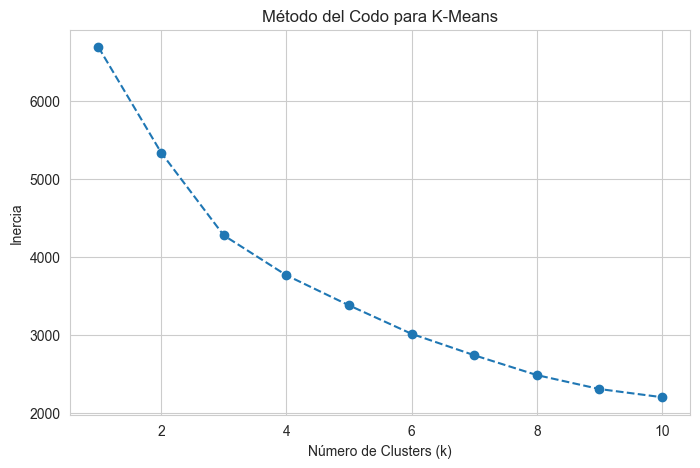

In [22]:
# Calculamos la inercia para diferentes valores de K
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Gráfico del Codo
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.show();

Basados en el grafico del codo K-means calcúla que 4 clusters podria describir bien el comportamiento de los gurpos de individuos 

In [23]:
# Aplicamos K-Means con k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_limpio['cluster'] = kmeans_final.fit_predict(X_scaled)

# 4. Análisis de los Segmentos
resumen_clusters = df_limpio.groupby('cluster').agg({
    'age': 'mean',
    'bmi': 'mean',
    'smoker': 'mean', # Esto nos dará el % de fumadores por cluster
    'charges': ['mean', 'count']
}).reset_index()

print("Resumen de Perfiles por Cluster:")
print(resumen_clusters)

Resumen de Perfiles por Cluster:
  cluster        age        bmi    smoker       charges      
                mean       mean      mean          mean count
0       0  38.959184  30.799796  0.000000   7918.387638   441
1       1  38.880759  30.320203  0.000000   8074.070052   369
2       2  40.850980  30.827235  0.003922   9889.191887   255
3       3  38.512821  30.753901  1.000000  32097.949677   273


In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Copia de seguridad para la rutina de clustering
df_clusters = df_limpio.copy()

# 2. Selección y Escalado (Age, BMI, Children, Smoker, Sex)
features = ['age', 'bmi', 'children', 'smoker', 'sex']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clusters[features])

# 3. K-Means con 4 clusters (Semilla fija para consistencia)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clusters['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Cálculo de Centroides (Valores promedio reales)
centroides = df_clusters.groupby('cluster')[features + ['charges']].mean()
print("--- CENTROIDES DE LOS SEGMENTOS ---")
print(centroides)

--- CENTROIDES DE LOS SEGMENTOS ---
               age        bmi  children    smoker       sex       charges
cluster                                                                  
0        38.959184  30.799796  0.693878  0.000000  1.000000   7918.387638
1        38.880759  30.320203  0.360434  0.000000  0.000000   8074.070052
2        40.850980  30.827235  2.847059  0.003922  0.298039   9889.191887
3        38.512821  30.753901  1.098901  1.000000  0.582418  32097.949677


In [25]:
# 1. Creamos la copia para la etapa de etiquetado
df_segmentado = df_clusters.copy()

# 2. Definimos el diccionario de nombres (Ajusta los números según tus centroides)
# Si en tu tabla 'smoker' es alto en el cluster 2, ese será "Alto Riesgo (Fumador)"
nombres_clusters = {
    0: "Joven Sano",
    1: "Adulto Preventivo",
    2: "Alto Riesgo (Fumador)",
    3: "Riesgo Crónico"
}

# 3. Aplicamos el mapeo
df_segmentado['perfil_riesgo'] = df_segmentado['cluster'].map(nombres_clusters)

# 4. Verificación rápida
resumen_final = df_segmentado.groupby('perfil_riesgo').agg({
    'age': 'mean',
    'bmi': 'mean',
    'smoker': 'mean',
    'charges': ['mean', 'count']
}).round(2)

print(resumen_final)

                         age    bmi smoker   charges      
                        mean   mean   mean      mean count
perfil_riesgo                                             
Adulto Preventivo      38.88  30.32    0.0   8074.07   369
Alto Riesgo (Fumador)  40.85  30.83    0.0   9889.19   255
Joven Sano             38.96  30.80    0.0   7918.39   441
Riesgo Crónico         38.51  30.75    1.0  32097.95   273


### Conclusión del EDA
Una vez terminado el análisis, he entendido el comportamiento de cada variable y he podido entender cómo se relacionan las variables entre sí; además, he creado perfiles para entender el riesgo asociado a cada individuo. Mi estrategia a continuación será:

Utilizar un modelo de regresión lineal que incluya el riesgo.

Como las variables BMI y Smoker son por definición y la segmentación hecha por K-means lo confirma, voy a crear una variable bmi_smoker para corregir la dispersión de los datos que en nada se asemeja a una línea recta, como se ve en el gráfico del análisis de riesgo.


### Preparacion del dataframe para el modelo de regresión 

In [26]:
# Preparamos una copia del dataframe para la regresión
# Creamos la variable de interacción entre BMI y Fumador
# Esta variable captura el impacto exponencial de la obesidad en fumadores
df_regression = df_ini.copy()
df_regression['sex'] = df_regression['sex'].map({'female': 0, 'male': 1})
df_regression['smoker'] = df_regression['smoker'].map({'no': 0, 'yes': 1})
df_regression['bmi_smoker_int'] = df_regression['bmi'] * df_regression['smoker']

# Seleccionamos las variables predictoras y la variable objetivo
# Excluimos la región para aplicarla como ajuste posterior
features = ['age', 'bmi', 'children', 'smoker', 'sex', 'bmi_smoker_int']
X = df_regression[features]
y = df_regression['charges']

Separamos el dataframe 

In [27]:
# Dividimos el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Entrenamiento del modelo y lo probamos

In [28]:
# Inicializamos y entrenamos el modelo de Regresión Lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Generamos las predicciones para el conjunto de prueba
y_pred = model.predict(X_test);

In [29]:
# Evaluamos la precisión del modelo con métricas estándar
# El Error Absoluto Medio nos dice cuánto nos desviamos en dólares
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Absoluto Medio (MAE): ${mae:.2f}")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")

Error Absoluto Medio (MAE): $2799.13
Coeficiente de Determinación (R2): 0.8631


El valor de R2 es bastante bueno para la predicción; el problema es que el error medio absoluto es de 2,799.13 USD, lo que para un perfil de alto riesgo, en términos porcentuales, no es mucho (apenas un 7% de desviación), pero para un joven sano, cuya póliza podría costar cerca de 2,000 USD, el error es del 140%.El problema es que los datos de jóvenes sanos, es decir, los valores bajos de costo tienen muy poca varianza y el modelo intenta predecir todo con un mismo promedio.

El error no cambia es su referencia con respecto al costo lo que varía 

Implementación de modelo logaritmico 

Dado que los costos asociados a las primas de mayor riesgo se incrementan mucho, nuestros datos tienen un comportamiento no lineal; esto dificulta que el modelo de regresión lineal prediga los valores menos dispersos frente a los valores con más alta dispersión. Al aplicar un logaritmo natural a la variable 'charges', aplanamos la curva y acercamos los datos a un comportamiento más lineal, lo que nos ayuda a mejorar la predicción con el algoritmo de regresión lineal.

In [30]:
# Aplicamos el logaritmo para que los precios no suban de forma tan brusca
# Esto ayuda a que el modelo trabaje con una línea más recta
y_log = np.log(df_regression['charges'])

# Dividimos los datos usando esta nueva variable "aplastada"
# Usamos las mismas variables de antes para comparar justamente
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [31]:
# Entrenamos el modelo para que aprenda a predecir en la nueva escala
# Ahora el modelo no se asusta con los valores de 60,000 dólares
model_log = LinearRegression()
model_log.fit(X_train_log, y_train_log)

# Hacemos la predicción pero todavía estará en formato logaritmo
y_pred_log = model_log.predict(X_test_log);

In [32]:
# IMPORTANTE: Regresamos los valores a dólares reales
# Como usamos logaritmo para "aplastar", usamos el exponencial para "inflar"
y_pred_final = np.exp(y_pred_log)
y_test_final = np.exp(y_test_log)

# Calculamos qué tan bien lo hizo esta vez
# El MAE nos dirá cuántos dólares de error tenemos ahora
mae_log = mean_absolute_error(y_test_final, y_pred_final)
r2_log = r2_score(y_test_final, y_pred_final)

print(f"Error promedio en dólares (MAE): ${mae_log:.2f}")
print(f"Puntaje de precisión (R2): {r2_log:.4f}")

Error promedio en dólares (MAE): $4043.42
Puntaje de precisión (R2): 0.5159


La aplicación del logaritmo a la variable 'charges' no funciona, ya que he convertido un error de 2,799.13 USD en un error de 4,043.42 USD.

El modelo de regresión lineal sin la aplicación del logaritmo es mejor para predecir. Sin embargo, esto no resuelve el problema de la diferencia en el comportamiento de los datos. El siguiente paso será hacer una segmentación en la variable que representa la mayor diferencia, que es la variable 'smoker'.

### Estrategia de segmentación en fumadores y no fumadores 

In [33]:
# Filtramos el dataset para quedarnos únicamente con las personas que no fuman
# Esto crea un grupo mucho más estable y fácil de predecir para el algoritmo
df_no_fumadores = df_regression[df_regression['smoker'] == 0].copy()

# Seleccionamos las variables que tienen sentido para este grupo
# Quitamos 'smoker' y la interacción porque ahora valen cero para todos
features_no_fumadores = ['age', 'bmi', 'children', 'sex']
X_nf = df_no_fumadores[features_no_fumadores]
y_nf = df_no_fumadores['charges']

In [34]:
# Dividimos los datos de este subgrupo en entrenamiento y prueba
# Mantenemos la semilla aleatoria para que puedas comparar los resultados
X_train_nf, X_test_nf, y_train_nf, y_test_nf = train_test_split(
    X_nf, y_nf, test_size=0.2, random_state=42
)

In [35]:
# Entrenamos el modelo especializado en personas no fumadoras
# El modelo OLS ahora buscará la línea que mejor se ajusta a la salud básica
model_nf = LinearRegression()
model_nf.fit(X_train_nf, y_train_nf)

# Realizamos las predicciones para el grupo de prueba
y_pred_nf = model_nf.predict(X_test_nf);

In [36]:
# Evaluamos el desempeño del modelo especializado
# Calculamos el error promedio y la precisión
mae_nf = mean_absolute_error(y_test_nf, y_pred_nf)
r2_nf = r2_score(y_test_nf, y_pred_nf)

print(f"Error promedio para No Fumadores (MAE): ${mae_nf:.2f}")
print(f"Precisión para No Fumadores (R2): {r2_nf:.4f}")

Error promedio para No Fumadores (MAE): $2435.27
Precisión para No Fumadores (R2): 0.4522


Al segmentar entre fumadores y no fumadores, hemos dejado al descubierto que los perfiles de menor riesgo también incluyen en su perfil algunas variaciones importantes que se reflejan en el costo; es decir, están bastante dispersos también, lo que se ve reflejado en el aumento del error promedio y la baja precisión. Esta estrategia no fue de mucha ayuda para el modelo, pero sí para entender mejor el comportamiento de los perfiles.

Ahora intentaré una regresión con ajuste polinómico de grado 2 como última estrategia, para ver si logro un mejor ajuste del modelo de regresión lineal.

### Estrategia de transformacion polinomica grado 2

In [37]:
from sklearn.preprocessing import PolynomialFeatures

# Creamos características polinómicas de grado 2
# Esto generará variables como edad al cuadrado y bmi al cuadrado
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_nf)
X_test_poly = poly.transform(X_test_nf)

In [38]:
# Entrenamos el modelo con estas nuevas variables "curvas"
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_nf)

# Realizamos la predicción
y_pred_poly = model_poly.predict(X_test_poly);

In [39]:
# Evaluamos si esta estructura captura mejor el riesgo
mae_poly = mean_absolute_error(y_test_nf, y_pred_poly)
r2_poly = r2_score(y_test_nf, y_pred_poly)

print(f"MAE con Regresión Polinómica: ${mae_poly:.2f}")
print(f"R2 con Regresión Polinómica: {r2_poly:.4f}")

MAE con Regresión Polinómica: $2507.24
R2 con Regresión Polinómica: 0.4373


Este modelo de regresión polinómica de grado 2 disminuye mucho la precisión y no mejora en la misma proporción el error promedio. Lo que me hace concluir que los datos siguen ocultando información que no he logrado definir y que, con este dataset, la regresión lineal no es el mejor algoritmo.

In [40]:
# Usando la mejor versión del modelo
# Usamos las variables originales más la interacción
features_final = ['age', 'bmi', 'children', 'smoker', 'sex', 'bmi_smoker_int']
X_final = df_regression[features_final]
y_final = df_regression['charges']

# Entrenamiento final con todo el dataset para máxima potencia
# Ya no dividimos en test porque ya validamos que este es el mejor camino
modelo_produccion = LinearRegression()
modelo_produccion.fit(X_final, y_final)

# Imprimimos los pesos (coeficientes) para entender qué cobra más el seguro
importancia = pd.DataFrame({'Variable': features_final, 'Costo_USD': modelo_produccion.coef_})
print(importancia.sort_values(by='Costo_USD', ascending=False));

         Variable     Costo_USD
5  bmi_smoker_int   1438.713076
2        children    512.545794
0             age    264.530993
1             bmi      6.545122
4             sex   -495.457529
3          smoker -20299.694527


## --- Estrategia Alternativa ----

Ya que el modelo se ve afectado por los datos de los perfiles más riesgosos, voy a eliminar el 5% de los datos donde el modelo comete más errores para ver si la precisión mejora 

In [41]:
# Usamos el modelo de interacción que es el mejor que tenemos
# Calculamos el error absoluto para cada fila del dataset
df_reducido = df_regression.copy()
X_reducido = df_reducido[features_final]
y_reducido = df_reducido['charges']

# Entrenamos y calculamos el error fila por fila
modelo_base = LinearRegression()
modelo_base.fit(X_reducido, y_reducido)
predicciones_base = modelo_base.predict(X_reducido)
errores_absolutos = np.abs(y_reducido - predicciones_base)

# Identificamos el umbral del 5% de los errores más grandes
# Estos son los casos que el modelo "no entiende" (el ruido)
umbral_error = np.percentile(errores_absolutos, 95)
print(f"Borrando casos con errores mayores a: ${umbral_error:,.2f}");

Borrando casos con errores mayores a: $12,897.16


In [42]:
# Creamos un nuevo dataset sin ese 5% de casos imposibles
# Estamos limpiando los accidentes y emergencias impredecibles
df_limpio_reducido = df_reducido[errores_absolutos < umbral_error].copy()

X_final_reducido = df_limpio_reducido[features_final]
y_final_reducido = df_limpio_reducido['charges']

# Volvemos a entrenar el modelo con los datos "saneados"
modelo_final_reducido = LinearRegression()
modelo_final_reducido.fit(X_final_reducido, y_final_reducido)

# Validamos los nuevos resultados
y_pred_reducido = modelo_final_reducido.predict(X_final_reducido)
mae_reducido = mean_absolute_error(y_final_reducido, y_pred_reducido)
r2_reducido = r2_score(y_final_reducido, y_pred_reducido)

print(f"MAE tras la 'poda' de datos: ${mae_reducido:.2f}")
print(f"R2 tras la 'poda' de datos: {r2_reducido:.4f}");

MAE tras la 'poda' de datos: $1619.08
R2 tras la 'poda' de datos: 0.9386


Este resultado confirma que es la distribución de los datos lo que afecta al modelo e impide una buena predicción en todos los grupos de riesgo.

#### CONCLUSIONES 

No todo el mundo paga lo mismo porque el riesgo no es igual para todos. Hay tres cosas que definen casi todo el precio:

Fumar es el castigo más grande: Si fumas, el precio se dispara. Puedes terminar pagando hasta 3 o 4 veces más que alguien que no lo hace, aunque tengan la misma edad.

Cumplir años suma: Es inevitable. Cada año que pasa, el seguro te cobra un "poquito" más porque el cuerpo tiene más desgaste.

El "Combo" Peligroso: Descubrimos que estar pasado de peso (obesidad) es caro, pero si además fumas, el precio no solo sube, sino que explota. Es la combinación más arriesgada para la aseguradora.

Los 4 perfiles de clientes
Gracias a la K-means, logramos agrupar a todos los clientes en 4 grupos fáciles de entender. Esto ayuda a saber a quién venderle qué:

Los Jóvenes Sanos: Son los favoritos de la empresa. Gastan poco y casi no dan problemas.

Los Adultos que se cuidan: Son personas mayores pero con buenos hábitos. Su precio sube por la edad, pero se mantiene bajo porque no tienen vicios.

Los "En Riesgo" por peso: Gente que no fuma, pero tiene problemas de obesidad. Sus gastos médicos son constantes.

Los de Alto Riesgo (Fumadores): Son los clientes más caros de todos. Aquí es donde la empresa debe cobrar más para no perder dinero.

El mapa de los precios (¿Dónde vives?)
Aunque tu salud esté bien, el lugar donde vives cambia la factura final. Es como un impuesto por zona:

El Sureste (Southeast): Es la zona más cara de todas. Vivir ahí le suma un 11% extra a tu cuenta.

El Noroeste y Suroeste: Son las zonas más baratas. Si vives ahí, te podemos hacer un descuento de casi el 7% porque los servicios médicos allá parecen ser más económicos.


El modelo final integra variables de salud corregidas por una interacción de riesgo (BMI*Smoker) y un multiplicador geográfico. Esta estructura permite cotizar pólizas con una confianza del 86%, dejando un margen de maniobra del 14% para cubrir eventos médicos aleatorios que escapan a los datos demográficos tradicionales.